# Описание
&emsp;[Это соревнование](https://www.kaggle.com/c/advanced-dls-spring-2021/) является домашним заданием к 3 модулю продвинутого потока [DLS](https://dls.samcs.ru) (осень 2023). Нам предстоит научитсья моделировать отток клиентов телеком компании.


# Первая часть. Исследование

In [1]:
import pandas as pd # импортируем пандас для чтения таблицы
import numpy as np # импортируем нампи для работы с данными

Загрузим данные. Воспользуемся предлоставленным kaggl'ом способом

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/advanced-dls-spring-2021/submission.csv
/kaggle/input/advanced-dls-spring-2021/train.csv
/kaggle/input/advanced-dls-spring-2021/test.csv


Если файлы с тренировочными и тестовыми данными в папке, то можем прочитать их.

In [3]:
df = pd.read_csv('/kaggle/input/advanced-dls-spring-2021/train.csv') # Чтение тренировачных данных
df.shape # определяем размерность загруженных данных

(5282, 20)

Видим, что перед нами таблица с 5 тысячами строк и 20 колонками, 19 из которых, скорее всего, признаки и 1 отклик. Проверим это выведя первые строки.

In [4]:
df.head(8)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.2,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0
5,25,19.80,475.2,Female,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
6,27,90.15,2423.4,Female,0,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,Yes,Month-to-month,No,Bank transfer (automatic),0
7,1,45.70,45.7,Male,0,No,No,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,1


Итак, что мы можем понять по колонкам.
1. **ClientPeriod**: Колонка, которая вероятно содержит информацию о том, сколько месяцев клиент уже является клиентом компании.
2. **MonthlySpending**: Содержит ежемесячный траты клиента на услуги компании.
3. **TotalSpent**: Содержит общую сумму, которую клиент потратил за все время своего обслуживания в компании.
4. **Sex**: Пол клиента.
5. **IsSeniorCitizen**: Бинарная колонка, которая показывает, является ли клиент пенсионером.
6. **HasPartner**: Указывает на наличие у клиента супруга.
7. **HasChild**: Указывает на наличие детей у клиента.
8. **HasPhoneService**: Указывает пользуется ли клиент услугой телефонной связи.
9. **HasMultiplePhoneNumbers**: Указывает на наличие у клиента нескольких телефонных номеров.
10. **HasInternetService**: Указывает пользуется ли клиент услугами предоставления интернет соединения.
11. **HasOnlineSecurityService**: Указывает на наличие у клиента услуги онлайн-безопасности.
12. **HasOnlineBackup**: Наличие у клиента услуги онлайн-резервирования данных.
13. **HasDeviceProtection**: Наличие у клиента услуги защиты устройств.
14. **HasTechSupportAccess**: Наличие у клиента доступа к технической поддержке.
15. **HasOnlineTV**: Наличие у клиента услуги онлайн-телевидения.
16. **HasMovieSubscription**: Наличие у клиента подписки на фильмы.
17. **HasContractPhone**: Эта колонка, вероятно, указывает на наличие у клиента контракта (лизинга) телефона.
18. **IsBillingPaperless**: Показывает, использует ли клиент электронными платёжками.
19. **PaymentMethod**: Метод оплаты, используемом клиентом.
20. **Churn**: Показывает, ушел ли клиент. Целевая переменная

&emsp;Примечание. Уже на этом этапе видно, что колонки **Sex**, **HasPartner**, **HasChild**, **HasPhoneService** можно переводить к биноминальному виду. Колонки **MultiplyPhoneNumbers**, **HasOnlineSecurityService**, **HasOnlineBackup**, **HasDeviceProtection**, **HasTechSupportAccess**, **HasOnlineTV**, **HasMovieSubscription** тоже можно свести к биноминальному виду т.к. все имеют фактически только два значения, а третье их значение отсылает к колонком **HasPhoneService/HasInternetService**. Также, возможно создание новых признаков. Например после ручной первых значений **TotalSpent** поделённых на **MonthlySpending** не всегда получалось значение из **ClientPeriod** +/- единица. Из этого можно сделать вывод, что некоторые пользователи проявляют активность управляя своим счётом после первичного подключения услуг (например заморозка счёта, отключение/подключение дополнительных услуг и т.д.), а некоторые нет. Можно предположить, что такие "активные" пользователи более вероятно могут уйти к другому опервтно, а также, возможно, такие пользователи более склонны к тому, чтобы остатья у данного оператора при предложении им бонусов.

Но для начала проверим наличие пропусков в значениях.

In [5]:
df.info() # Вывод информации о колонках датасета

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

По сводной таблице видно, что пропусков значений в таблице нет. Однако есть большое несоответствие по типам данных. Следует перевести такие колонки к значением с плавающей запятой (**TotalSpent**) и к булевым значениям (**Sex**, **HasPartner**, **HasChild**, **HasPhoneService**)

In [6]:
#df['TotalSpent'] = df['TotalSpent'].astype(float) # Выдаёт ошибку. Почему? Сейчас раберёмся

Ячейка сверху выдаёт ошибку при попытке конвертировать значения. Чтобы понять, что может быть не так исследуем значения в этой колонке при помощи метода value_counts()

In [7]:
df['TotalSpent'].value_counts() # Смотрим какие значения встречаются в колонке

TotalSpent
           9
20.2       9
19.75      8
20.05      6
19.65      6
          ..
41.85      1
4326.25    1
950.2      1
4264       1
1375.6     1
Name: count, Length: 4978, dtype: int64

В первой же строчке видим, что есть 9 строк в которых отсутствуют числовые значения. Выведем эти строки, чтобы узнать есть ли в них проблемы с другими значениями. Для этого используем маску

In [8]:
df[df['TotalSpent'] == ' '] # выводим строки с пустой строкой вместо значений

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
1048,0,25.75,,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
1707,0,73.35,,Female,0,Yes,Yes,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,0
2543,0,19.70,,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,0
3078,0,80.85,,Female,0,Yes,Yes,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,0
3697,0,20.00,,Female,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
4002,0,61.90,,Male,0,No,Yes,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),0
4326,0,25.35,,Male,0,Yes,Yes,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,0
4551,0,52.55,,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),0
4598,0,56.05,,Female,0,Yes,Yes,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),0


&emsp;Исходя из таблицы, можно сделать вывод, что пользователи у которых пустая строка в **TotalSpent** это новые пользователи у которых значение **ClientPeriod** равно нулю. Можно превратить пустые значения в 0 или добавить **MonthlySpending** к **TotalSpent**. Второй вариант, на мой взгляд, выглядит разумнее. Сдвиг всего вектора не должен повлиять на работу модели

In [9]:
def preproc_num(df): # создадим фкнкцию, чтобы не плодить код когда нам понадобится обработать тестувую таблицу
    df['ClientPeriod'] += 1 # увеличение на единицу колонки ClientPeriod
    df[df['TotalSpent'] == ' '] = df[df['TotalSpent'] == ' '].replace(' ', 0)  # заменяем пустые строки на нули
    df['TotalSpent'] = df['TotalSpent'].astype(float) # приводим строки к типу с плавающей запятой
    df['TotalSpent'] += df['MonthlySpending'] # увеличиваем TotalSpent на величину MothlySpending
    return df
preproc_num(df)
df.iloc[1048] # Проверяем, что всё корректно

ClientPeriod                                  1
MonthlySpending                           25.75
TotalSpent                                25.75
Sex                                        Male
IsSeniorCitizen                               0
HasPartner                                  Yes
HasChild                                    Yes
HasPhoneService                             Yes
HasMultiplePhoneNumbers                     Yes
HasInternetService                           No
HasOnlineSecurityService    No internet service
HasOnlineBackup             No internet service
HasDeviceProtection         No internet service
HasTechSupportAccess        No internet service
HasOnlineTV                 No internet service
HasMovieSubscription        No internet service
HasContractPhone                       Two year
IsBillingPaperless                           No
PaymentMethod                      Mailed check
Churn                                         0
Name: 1048, dtype: object

Теперь приведём те категориальные признаки которое возможно к булеву типу.

In [10]:
def preproc_bool(df):
    df['Sex'] = df['Sex'].replace({'Female': True, 'Male': False})
    df['IsSeniorCitizen'] = df['IsSeniorCitizen'].astype(bool)
    df['HasPartner'] = df['HasPartner'].replace({'Yes': True, 'No': False})
    df['HasChild'] = df['HasChild'].replace({'Yes': True, 'No': False})
    df['HasPhoneService'] = df['HasPhoneService'].replace({'Yes': True, 'No': False})
    df['IsBillingPaperless'] = df['IsBillingPaperless'].replace({'Yes': True, 'No': False})
    return df
preproc_bool(df)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,56,19.50,1045.85,False,False,True,True,True,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,False,Mailed check,0
1,73,25.85,1898.05,False,False,True,False,True,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,False,Credit card (automatic),0
2,2,75.90,151.80,False,False,False,False,True,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,True,Electronic check,1
3,33,79.30,2649.30,True,True,True,False,True,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,False,Mailed check,0
4,61,115.25,6873.70,True,False,True,True,True,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,False,Credit card (automatic),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5277,4,30.40,112.55,False,False,False,False,False,No phone service,DSL,No,No,No,Yes,No,No,Month-to-month,False,Electronic check,0
5278,51,44.45,2232.90,False,False,True,False,False,No phone service,DSL,Yes,No,No,Yes,Yes,No,One year,True,Bank transfer (automatic),0
5279,2,55.05,110.10,False,False,False,False,True,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,False,Mailed check,0
5280,30,76.00,2291.25,True,False,False,False,True,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Credit card (automatic),0


Мы могли перевести ещё некоторые признаки к булевому типу, но не будем делать этого, т.к. скорее всего это не пригодится. 
Проверим, что всё корректно

In [11]:
df.tail(3)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
5279,2,55.05,110.10,False,False,False,False,True,No,DSL,No,No,Yes,Yes,No,No,Month-to-month,False,Mailed check,0
5280,30,76.00,2291.25,True,False,False,False,True,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,True,Credit card (automatic),0
5281,20,75.90,1451.50,True,False,False,True,True,Yes,DSL,Yes,Yes,No,Yes,Yes,No,Month-to-month,True,Mailed check,0


Теперь разделим нашу таблицу на признаки и отклик

In [12]:
num_features = ['ClientPeriod','MonthlySpending','TotalSpent'] # присваиваем названия численных и булевых колонок списку
bool_features = ['Sex','IsSeniorCitizen','HasPartner','HasChild', 'HasPhoneService','IsBillingPaperless'] # присваиваем названия булевых
cat_features = ['HasMultiplePhoneNumbers', 'HasInternetService', 'HasOnlineSecurityService', 'HasOnlineBackup', 
                'HasDeviceProtection', 'HasTechSupportAccess', 'HasOnlineTV', 'HasMovieSubscription', 
                'HasContractPhone', 'PaymentMethod'] # присваиваем названия категориальных колонок списку
features = num_features + bool_features + cat_features # конкатенируем список численных и категориальных названий 
target = 'Churn' # отделяем таргет
len(features) # проверяем, что ничего не забыли

19

Переходим к анализу данных

# Анализ данных

In [13]:
from matplotlib import pyplot as plt 
import seaborn as sns

Построим для численных призанков гистограмму и boxplot (ящик с усами) 

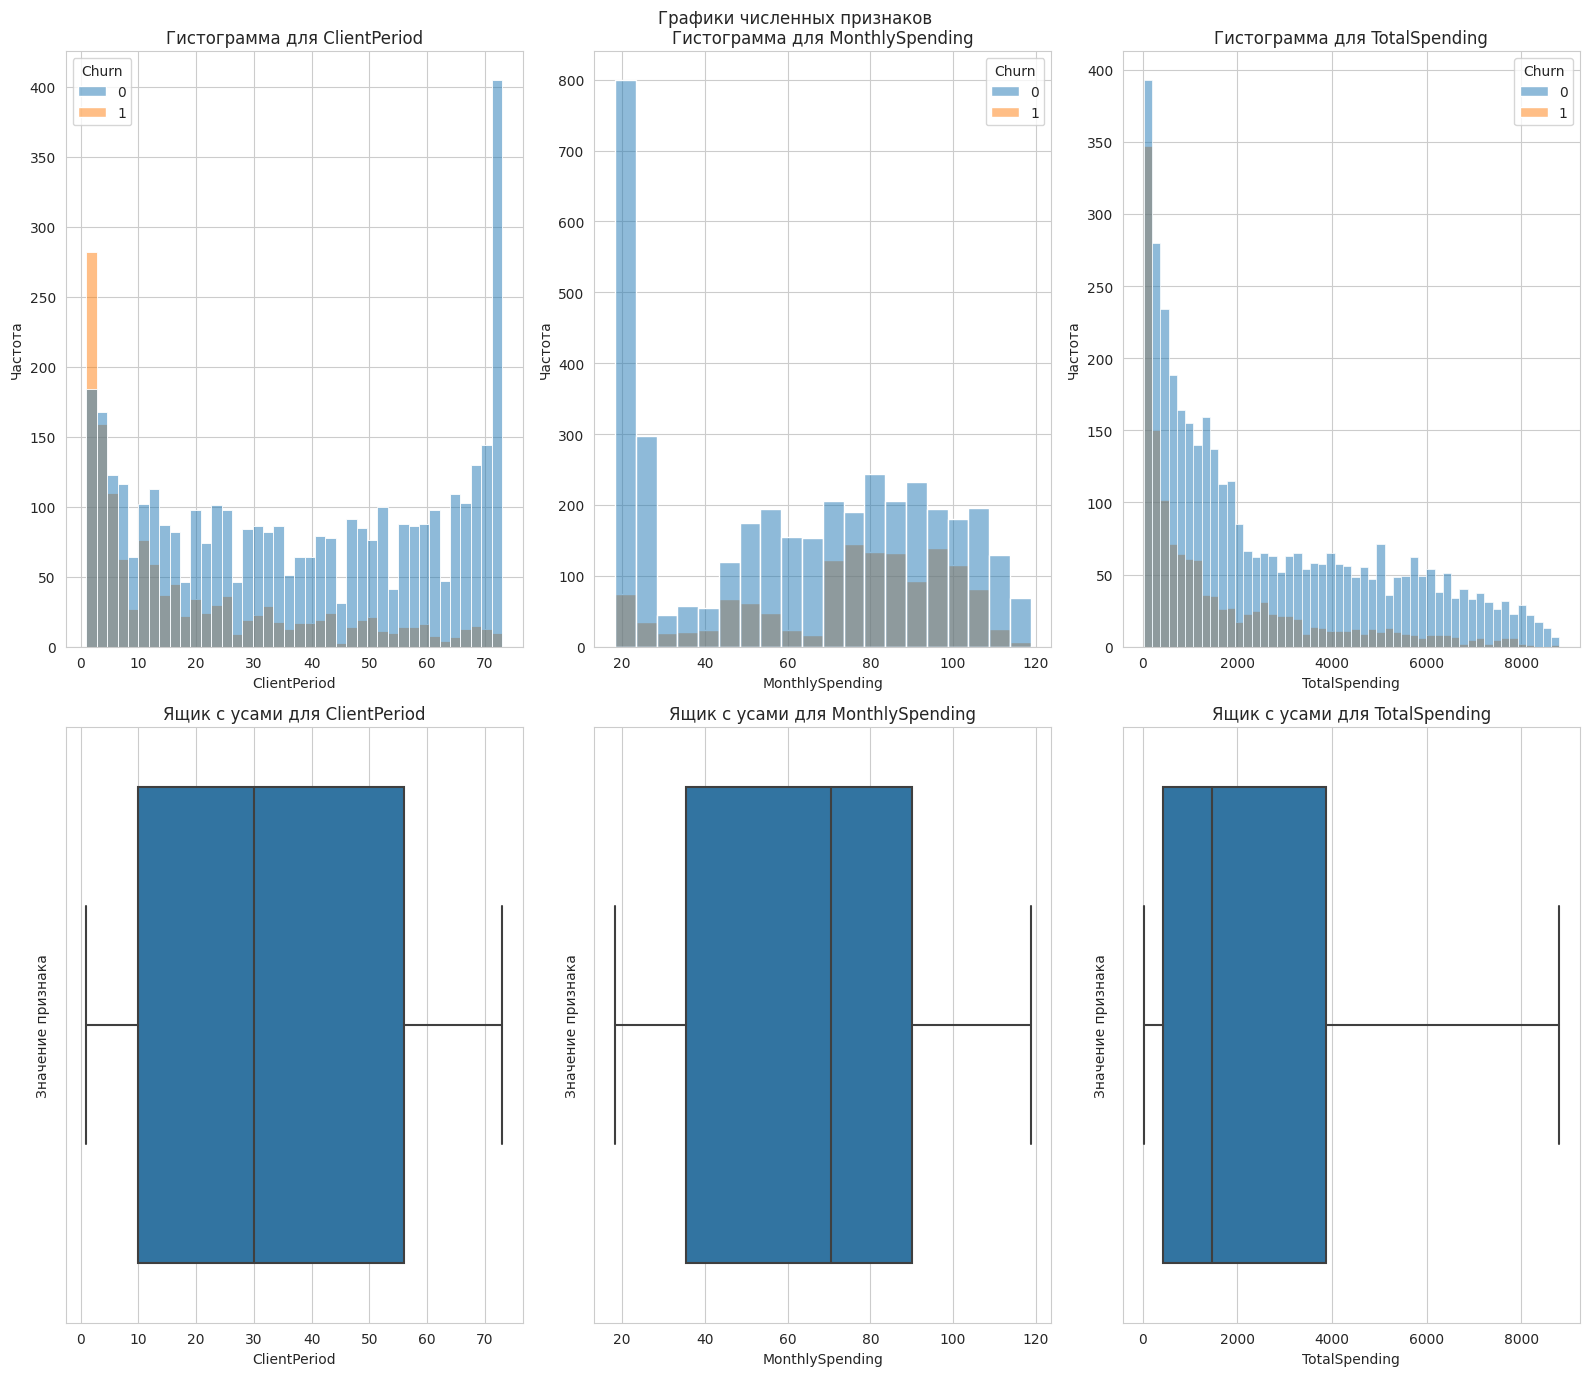

In [14]:
colors = ['red', 'green', 'blue'] # цвета по которым будем итерироваться
bins = [40, 20, 50] # количество корзин для гистограм для итерации
X_labels = ['ClientPeriod', 'MonthlySpending', 'TotalSpending'] # названия признаков для итерации
sns.set_style('whitegrid') # добавляем к графикам сетку
plt.figure(figsize=(16,14)) # создание полотна для подграфикоф
plt.suptitle('Графики численных признаков') # название полотна
for i in range(1,4): # запускаем цикл на 3 подграфика
    plt.subplot(2, 3, i) # задаём положжение подграфика
    sns.histplot(data=df, x=num_features[i-1], bins=bins[i-1], color=colors[i-1], hue='Churn') # создание гистограммы
    plt.xlabel(X_labels[i-1]) # подписываем ось абсцисс
    plt.ylabel('Частота') # подписываем ось ординат
    plt.title(f'Гистограмма для {X_labels[i-1]}') # подписываем подграфик
for i in range(1,4): # запускаем цикл на 3 подграфика
    plt.subplot(2, 3, i+3) # задаём положжение подграфика
    sns.boxplot(data=df, x=num_features[i-1], hue='Churn') # создание гистограммы
    plt.xlabel(X_labels[i-1]) # подписываем ось абсцисс
    plt.ylabel('Значение признака') # подписываем ось ординат
    plt.title(f'Ящик с усами для {X_labels[i-1]}') # подписываем подграфик    
plt.tight_layout()
plt.show()

Построим круговые графики для категориальных и булевых признаков круговые диаграммы.

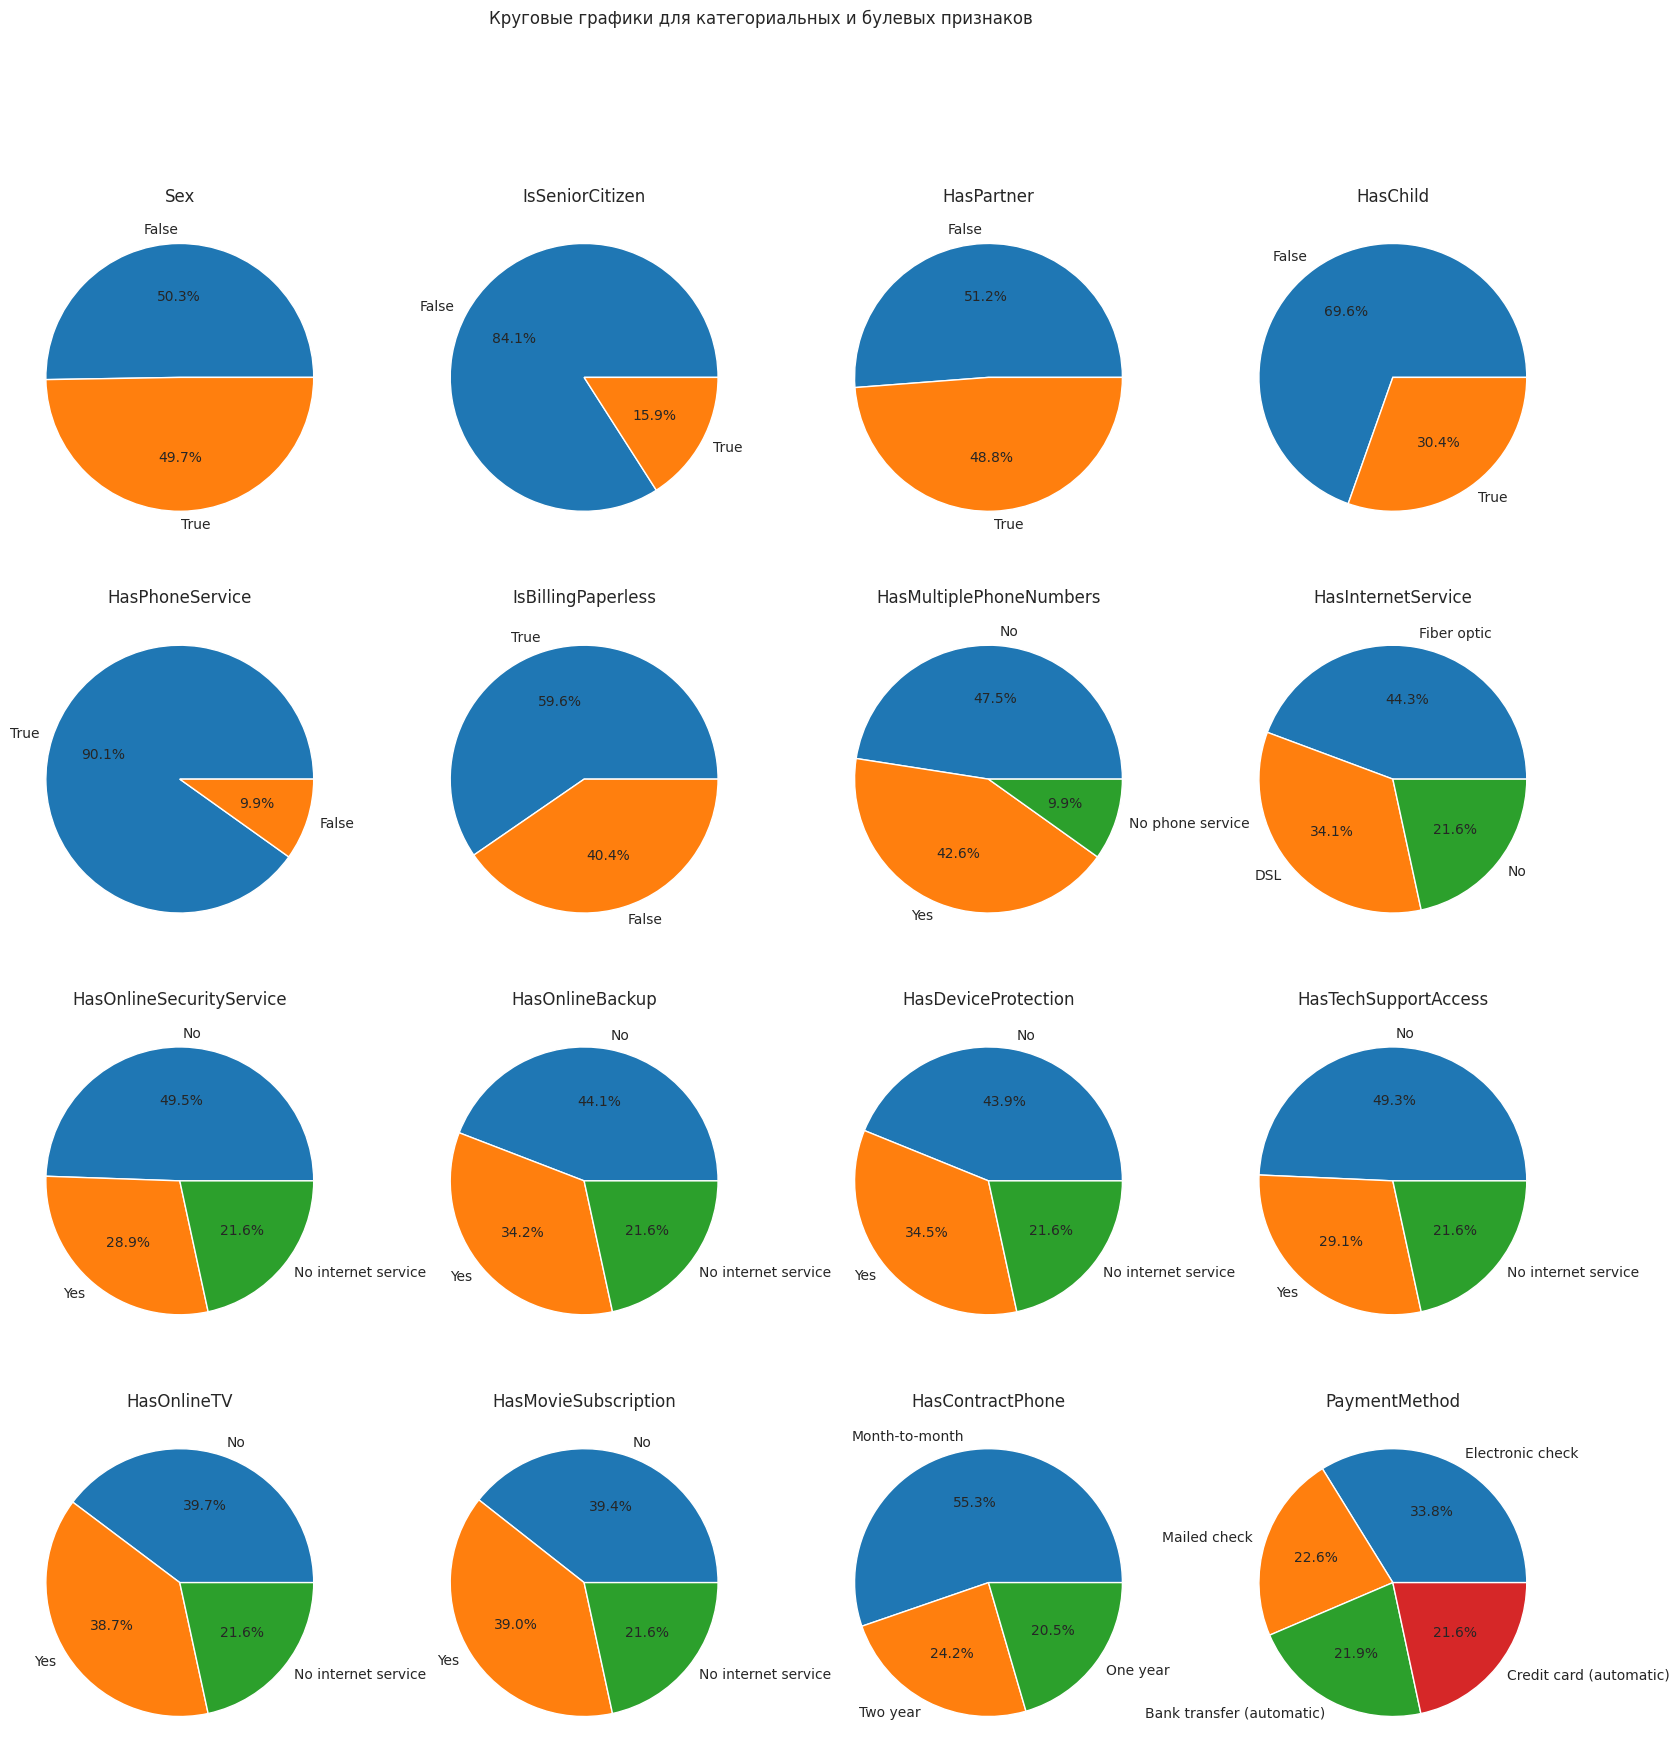

In [15]:
cat_and_bool = bool_features + cat_features # конкатенируем булевы и категориальные признаки, чтобы по ним можно было итерироваться
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 20)) # Returns fig : `.Figure` ax : `~matplotlib.axes.Axes` or array of Axes
ax_array = axes.ravel() # ravel() из массива 3х3 делает 1х9. Нужно для итерации
fig.suptitle('Круговые графики для категориальных и булевых признаков') # подпись полотна
for i, feature in enumerate(cat_and_bool): # итерация по списку признаков
    x = df[feature].value_counts() #  "Раскладываем" каждый признак на количество его уникальных значений
    n = x.index # Присваиваем список возможных уникальных значений. Для биноминальных это 1 и 0, для категориальных его возможные значения
    ax_array[i].pie(x=x, labels=n, autopct='%.1f%%') # Строим круговую диаграмму
    ax_array[i].set_title(feature)  # Подписываем диаграмму

Также построим круговую диаграмму для отклика, чтобы понять сбалансированны ли классы

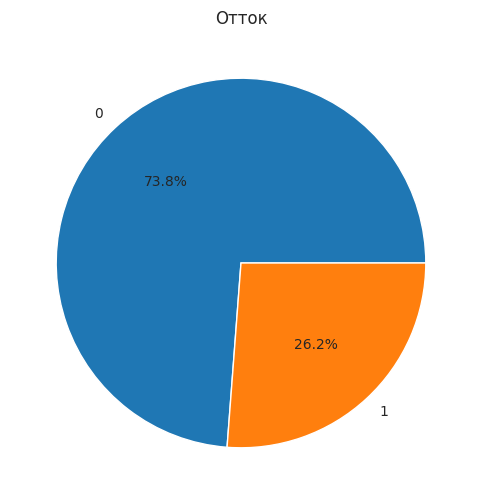

In [16]:
x = df[target].value_counts() 
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
n = x.index
axes.pie(x=x, labels=n, autopct='%.1f%%')
axes.set_title('Отток') 
plt.show()

Отношение классов в нашей выборки ~1/3, а следовательно выборку нельзя считать сбалансированной.

Построим тепловую карту корреляций признаков в нашей выборку

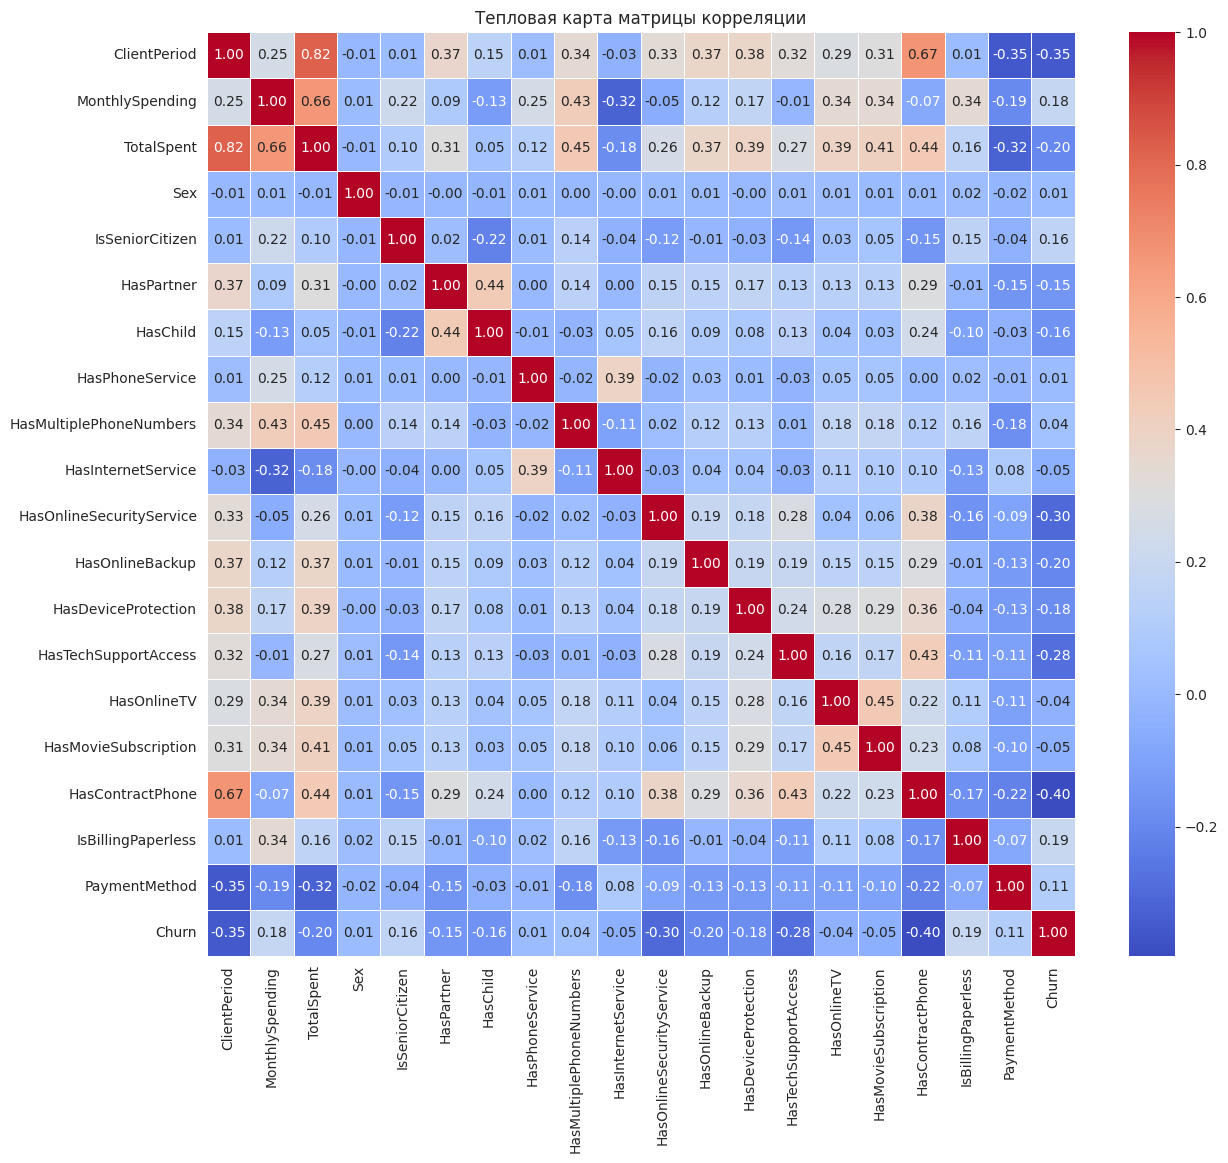

In [17]:
from sklearn.preprocessing import LabelEncoder # импортируем кодировку признаков чтобы можно было использовать np.corr()
corr_matrix = df.copy() # копируем нашу таблицу
label_encoder = LabelEncoder() # загружаем LabelEncoder
for cat_feature in cat_features: # делаем цикл т.к. LabelEncoder может кодировать только 1 колонку за раз
    corr_matrix[cat_feature] = label_encoder.fit_transform(corr_matrix[cat_feature])

corr_matrix = corr_matrix.corr() # используем метод np.corr() на закодированную таблицу
plt.figure(figsize=(14, 12))  # строим полотно для тепловой карты
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f') # строим тепловую карту
plt.title('Тепловая карта матрицы корреляции') # подписываем карту
plt.show()

По тепловой карте матрицы корреляции видно, что с целевым парметром сильнее всех отрицательно коррелирует наличие контракта на телефон (-0.4) и длительность пользования услугами компании (-0.35). Сильнее всех положительно коррелирует наличие электронной платёжки (0.19) и величина месячных трат на услуги (0.18). Меньше всех с целевым признаком коррелирует пол клиента (0.01) и пользование телефонными услугами (0.01)

# Применение линейных моделей 

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [19]:
# разбиваем наши данные на признаки и отклик
y_train = df[target] # отклик
X_train = df.iloc[:, :-1] # признаки

Для логистической регрессии нам необходимо отнормировать числовые признаки. Воспользуемся StandardScaler. 

In [20]:
# Код ниже может вызвать некритичные предупреждения. И, чтобы красное полотно текста нас не смущало, проигнорируем их.
import warnings
warnings.filterwarnings('ignore')

## ВНИМАНИЕ
Закоментированная секция кода перебирает большое количество параметров. Чтобы не терять на это время в исполняемой части оставлены подобранные параметры из тех, что перебирались в закомментированной части. 

In [21]:
# a = LogisticRegression(random_state=42) # строрка для удобства вызова справки логистической регересии не более
# согласно документации следующие солверы будут работать только со следующими типами ругуляризации.
# сейчас я буду пробовать все типы солверов сашка.png
       # - 'lbfgs'           -   ['l2', None]
       # - 'liblinear'       -   ['l1', 'l2']
       # - 'newton-cg'       -   ['l2', None]
       # - 'newton-cholesky' -   ['l2', None]
       # - 'sag'             -   ['l2', None]
       # - 'saga'            -   ['elasticnet', 'l1', 'l2', None]

# C = [150, 120, 100, 90, 70, 60, 50, 10, 1, 0.1, 0.01, 0.001]
# max_iter = [50, 80, 100, 125, 150]
# solvers = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
# solver_params = {
#     'lbfgs': {'clf__penalty': ['l2'], 'clf__C': C},
#     'liblinear': {'clf__penalty': ['l1', 'l2'], 'clf__C': C},
#     'newton-cg': {'clf__penalty': ['l2'], 'clf__C': C},
#     'newton-cholesky': {'clf__penalty': ['l2'], 'clf__C': C},
#     'sag': {'clf__penalty': ['l2'], 'clf__C': C},
#     'saga': {'clf__penalty': ['elasticnet', 'l1', 'l2'], 'clf__C': C}
# }
# hyperparams = [{'clf__solver': [solver], **params} for solver, params in solver_params.items()]
# Лучшая оценка: 0.8451501048863118

hyperparams = [{'LogReg__C': [10], 'LogReg__penalty': ['l2'],
                'LogReg__solver': ['lbfgs'], 
                'LogReg__max_iter': [100]}] # лучшие параметры из итерируемых
preprocess = ColumnTransformer([ # применяем стандартную нормировку к числовым признакам и OHE к категориальным
        ("num", StandardScaler(), num_features),
        ("cat_ohe", OneHotEncoder(), cat_and_bool)
    ])
pipe = Pipeline([ # создаём конвеер
        ("preprocess", preprocess),
        ("LogReg", LogisticRegression(random_state=42))
    ])
logreg = GridSearchCV(pipe, hyperparams, scoring='roc_auc', refit=True, n_jobs=-1, cv=5) # выполнение кросс-валидации
logreg.fit(X_train, y_train)
print(f'Итоговые параметры:', logreg.best_params_)
print(f'Лучшая оценка:', logreg.best_score_)

/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Итоговые параметры: {'LogReg__C': 10, 'LogReg__max_iter': 100, 'LogReg__penalty': 'l2', 'LogReg__solver': 'lbfgs'}
Лучшая оценка: 0.8451501048863118


Итоговые параметры: {'clf__C': 10, 'clf__max_iter': 100, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Лучшая оценка: 0.845150104886311

Теперь надо загрузить тестовую выборку и сделать оценку вероятности

In [22]:
X_test = pd.read_csv('/kaggle/input/advanced-dls-spring-2021/test.csv') # загружаем тестовую выборку
preproc_num(X_test) # применяем напписанные нами ранее функции к тестовой выборке
preproc_bool(X_test)
logreg.predict_proba(X_test) # вызываем обученную модель для предсказания вероятности принадлежанию классу
submission = pd.Series(logreg.predict_proba(X_test)[:, 1]) # присваиваем рузльтат предсказания модели (только принадлеждности к 1му классу)
submission = pd.DataFrame({
    'Id': range(len(submission)),
    'Churn': submission
    })
submission.to_csv('logreg_proba.csv', index=False) # записываем результат в csv таблицу

![image.png](https://sun9-17.userapi.com/impg/1xJSbIajGaG8XcYVWLx-aYc08nvnvk_EnRnPpw/e69KPBEZ_-s.jpg?size=884x126&quality=96&sign=66587da185e574763a3c66d7a7e4c331&type=album)

Логистическая регрессия на тестовой выборке дала нам даже лучший результат, чем на тренировочной на 5 тысячных процента. Попробуем улучшить результат использованием градиентного бустинга

# Применение градиентного бустинга

In [23]:
#!pip install catboost

In [24]:
from catboost import CatBoostClassifier, cv, Pool

Вернём данные к исходным, т.к. catboost не требует кодировки признаков

In [25]:
# Но сначала сохраним обработанные данные
df = pd.read_csv('/kaggle/input/advanced-dls-spring-2021/train.csv')
preproc_num(df) # заново обрабатываем численные данные
y_train_cat = df[target] # отклик
X_train_cat = df.iloc[:, :-1] # признаки

Приступим к обучению. Также оставлен лучший из перебранных вариантов

In [26]:
# params = {
#     'iterations': [200, 250, 300], # количество деревьев 
#     'depth': [4, 5, 6], # глубина деревьев
#     'l2_leaf_reg': [3, 1], # коэффициент l2 регуляризации
#     'subsample': [0.5, 0.7], # количество признаков случайно выбираемых из датасета
#     'eta': [0.03, 0.05], # скорость градиентного спуска (этот параметр альтернатива learning_rate)
#     'grow_policy': ['SymmetricTree', 'Lossguide'], # выбор политики роста (см документацию)
#     'random_seed': [42], # датчик случайных чисел для возможности воспроизведения результата
# }

params = {'depth': [4],
          'random_seed': [42],
          'l2_leaf_reg': [1],
          'iterations': [200],
          'subsample': [0.5],
          'learning_rate': [0.05],
          'grow_policy': ['Lossguide']} # лучшие найденные параметры
catboost = CatBoostClassifier(silent=True, cat_features=cat_and_bool, eval_metric = 'AUC:hints=skip_train~false',)
best_params = catboost.grid_search(params, X_train_cat, y_train, refit=True)


bestTest = 0.8754704994
bestIteration = 57

0:	loss: 0.8754705	best: 0.8754705 (0)	total: 1.72s	remaining: 0us
Estimating final quality...
Training on fold [0/3]

bestTest = 0.8370529471
bestIteration = 195

Training on fold [1/3]

bestTest = 0.8491981985
bestIteration = 126

Training on fold [2/3]

bestTest = 0.8581830843
bestIteration = 130



In [27]:
print('Лучшие параметры: ',best_params['params'])

Лучшие параметры:  {'depth': 4, 'random_seed': 42, 'l2_leaf_reg': 1, 'iterations': 200, 'subsample': 0.5, 'learning_rate': 0.05, 'grow_policy': 'Lossguide'}


In [28]:
X_test = pd.read_csv('/kaggle/input/advanced-dls-spring-2021/test.csv') # загружаем тестовую выборку
preproc_num(X_test)
submission = pd.Series(catboost.predict_proba(X_test)[:, 1])
submission = pd.DataFrame({
    'Id': range(len(submission)),
    'Churn': submission
    })
submission.to_csv('submission.csv', index=False)

![image.png](https://sun9-56.userapi.com/impg/7vHpUPW0XIPm2UmWWs6qa5-OfuixUoqI1n_7pg/nO1XGmKCz8I.jpg?size=1207x167&quality=96&sign=a14ab71a841cea15aa39c9bf3c675cd2&type=album)

Использование градиентного спуска улучшило результат на процент.